# Лабораторная 1 – Гусев Иван

In [ ]:
# Внешние импорты
import pandas as pd
from nltk.corpus import stopwords
import pymorphy3
import statistics
import string
import re
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from gensim.models import Word2Vec
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random
# Внутренние импорты
from writers_and_readers import fb2reader, txt_reader, epub_reader

## Первая часть

### Объединяем .csv

In [302]:
negative = pd.read_csv("negative.csv", header=None, sep=';')
positive = pd.read_csv("positive.csv", header=None, sep=';')
dataset = pd.concat([negative, positive])
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


### Удаляем стоп-слова

In [303]:
morph = pymorphy3.MorphAnalyzer()

In [ ]:
stop_words = set(stopwords.words("russian"))
stop_words.remove("хорошо")

print(stop_words)

{'он', 'чтобы', 'уже', 'может', 'по', 'к', 'все', 'мы', 'мой', 'она', 'если', 'тогда', 'лучше', 'тебя', 'ты', 'эти', 'всю', 'вас', 'ним', 'они', 'мне', 'ничего', 'них', 'ему', 'когда', 'уж', 'куда', 'ведь', 'разве', 'только', 'опять', 'тоже', 'совсем', 'всех', 'потом', 'можно', 'потому', 'тем', 'раз', 'больше', 'об', 'какая', 'быть', 'чтоб', 'будто', 'свою', 'о', 'моя', 'этого', 'всего', 'ни', 'чем', 'наконец', 'им', 'будет', 'нибудь', 'ли', 'над', 'от', 'нельзя', 'в', 'вы', 'и', 'этот', 'почти', 'то', 'впрочем', 'не', 'много', 'была', 'этом', 'вдруг', 'надо', 'себе', 'сейчас', 'себя', 'был', 'еще', 'ж', 'меня', 'как', 'есть', 'были', 'него', 'перед', 'более', 'его', 'было', 'конечно', 'три', 'с', 'нет', 'при', 'их', 'между', 'всегда', 'после', 'под', 'эту', 'теперь', 'такой', 'вот', 'за', 'для', 'того', 'или', 'тут', 'хоть', 'что', 'здесь', 'два', 'через', 'иногда', 'из', 'во', 'со', 'же', 'ну', 'никогда', 'вам', 'на', 'даже', 'у', 'но', 'а', 'тот', 'про', 'до', 'том', 'я', 'так', 'ей

In [305]:
def text_preprocess(text: str) -> str:
    """
    Функция предобработки текст: приведение к нижнему регистру, токенизация, лемматизация
    """
    normalized_text = text
    normalized_text = normalized_text.lower()
    normalized_text = [word for word in normalized_text.split() if word not in stop_words]
    normalized_text = [morph.parse(word)[0].normal_form for word in normalized_text]
    normalized_text = " ".join(normalized_text)
    normalized_text = normalized_text.translate(str.maketrans('', '', string.punctuation))
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    return normalized_text

In [306]:
# Применяем предобработку текста ко всему датасету
dataset.iloc[:, 3] = dataset.iloc[:, 3].apply(text_preprocess)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,работа полный пиддес каждый закрытие месяца с...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,коллега сидеть рубиться urban terror изза долб...,-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,elina4post говорить обещаной год ждут,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,желать хороший полёт удачный посадкить быть оч...,-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,обновить какойто леший surf работать простоплеер,-1,0,0,0,35,17,34,0


### Делаем sentiment-анализ

In [307]:
# Считываем LinisCrowd 2015
sentiment_dataset = pd.read_csv("words_all_full_rating.csv", encoding="cp1251", sep=";", index_col="Words")
sentiment_dataset.head()

,mean,dispersion,average rate,Unnamed: 4
Words,,,,
аборигенный,"-0,25","0,433012701892219",0,NaN
аборт,-1,"0,816496580927726",-1,NaN
абрамович,0,0,0,NaN
абсолютный,"0,333333333333333","0,471404520791032",0,NaN
абстрактный,"-0,111111111111111","0,87488976377909",0,NaN


In [272]:
def sentiment_analysis(text: str, sentiment_df: pd.DataFrame) -> list:
    """
    Функция, которая преобразует текст в вектор из 
    среднего, максимального, минимального, 
    суммарного значения и количества положительных и отрицательных значений
    """
    
    def count_metrics(embedded_sentence):
        """
        Функция, которая считает по векторам предложений метрики
        (среднее, максимальное, минимальное, суммарное значение и количество положительных и отрицательных значений)
        """
        return [
            statistics.mean(embedded_sentence), max(embedded_sentence), 
            min(embedded_sentence), sum(embedded_sentence), 
            embedded_sentence.count(1), embedded_sentence.count(-1)
            ]
    

    processed_text = text.split()
    embedded_text = []
    for word in processed_text:
        try:
            word_sentiment = (sentiment_df.loc[word]["average rate"])
            embedded_text.append(float(word_sentiment))
        except KeyError:
            pass
    # Если ни для одного слова не нашлось значения, записываем ноль
    if len(embedded_text) == 0:
        return [0.0]
    return count_metrics(embedded_text)

In [273]:
# Получаем лейблы X – тексты, преобразованные в вектора
X_labels = list(map(lambda text: sentiment_analysis(text, sentiment_dataset), dataset.iloc[:, 3].to_list()))
# Получаем лейблы Y – значения -1 и 1 из колонки 4
Y_labels = dataset.iloc[:, 4].to_list()

len(X_labels), len(Y_labels)

(226834, 226834)

### Извлекаем морфологические признаки

In [274]:
def get_relative_POS(text):
    if not isinstance(text, str):
        return ""
    try:
        sentence_POS = [morph.parse(word)[0].tag.POS for word in text.split()]
        # Удаляем None
        sentence_POS = [POS for POS in sentence_POS if POS]
        # Смотрим на все части речи, которые есть в предложении
        POS_unique = set(sentence_POS)
        sentence_POS_count = {}
        for POS in POS_unique:
            sentence_POS_count[POS] = sentence_POS.count(POS) / len(sentence_POS)
    except TypeError:
        pass
    return sentence_POS_count

In [275]:
POS_frequency = dataset.iloc[:, 3].apply(get_relative_POS)
POS_frequency.to_csv("POS_frequency.csv")

### Извлекаем признаки с помощью мешка слов

In [ ]:
vectorizer = TfidfVectorizer()
svd = TruncatedSVD(n_components=1000, random_state=42)


corpus = dataset.iloc[:, 3].to_list()
# Извлекаем признаки
X = vectorizer.fit_transform(corpus)
# Сокращает размерность
# TrunkatedSVD оптимизирован под разреженные матрицы, такие как Tf-Idf
X_svd = svd.fit_transform(X)

X_svd[0].shape

(1000,)


In [ ]:
# Сохраняем полученные вектора
np.save("tf_idf.npy", X_svd)
X_svd[0]

array([ 2.04130359e-02, -9.82406864e-03, -1.07027693e-02, -6.71350567e-03,
        1.82991786e-03,  7.12516959e-04, -3.16149306e-03, -1.06403422e-02,
       -1.78786825e-03, -2.64097611e-03, -4.78302703e-03, -7.14419656e-04,
       -1.06626484e-03, -2.20465604e-03,  3.06342338e-03, -2.33933341e-03,
        8.02776968e-03, -3.35237029e-03, -5.03409038e-03,  6.35967781e-03,
       -1.02200852e-03, -6.45004623e-05, -1.60426278e-03,  1.04662396e-02,
        1.04403111e-02, -2.69855434e-03, -8.11332676e-03,  1.65983133e-03,
        4.13256239e-03,  1.03253810e-02,  8.51807764e-03,  1.21114095e-02,
        1.39740993e-03,  3.18391606e-03, -8.01555584e-03, -2.32981648e-03,
        9.96686823e-04,  2.09814684e-03, -8.73023655e-03, -5.18775694e-03,
        5.24413348e-03, -4.66612868e-03, -2.83213052e-03, -5.68213928e-03,
        5.30272556e-03,  1.41568449e-02,  1.15253148e-03, -1.84562947e-02,
        8.49204288e-03, -1.71165000e-04,  2.29054547e-04, -2.84901154e-03,
        8.80797629e-03,  

## Вторая часть

### Word2vec

Берем корпус литературных текстов и объединяем их в список из списков (по предложениям): так нужно для word2vec

In [350]:
# Для word2vec не используем nltk-библиотеку со стоп-словами, а делаем своё
# Нам нужно сохранить каркас языка, но удалить шум: слова-паразиты, вводные слова
# nltk выбрасвает много полезного для wav2vec: местоимения, союзы

stopwords = {
    # Разговорный шум
    "вот", "ну", "ага", "ладно", "типа", "короче",
    "вообще", "просто", "как бы", "вроде",
    "кажется", "разве", "кстати", "значит",
    # Усилители / модальные
    "очень", "реально", "буквально", "фактически",
    "примерно", "почти", "вполне", "совсем",
    # Вводные и связки
    "например", "итак", "итого", "впрочем",
    "собственно", "действительно", "между прочим",
    # Реплики речи
    "сказал", "сказала", "сказали",
    "говорил", "говорила", "говорили",
    "спросил", "спросила", "ответил", "ответила",
    # Временные маркеры без смысла
    "сейчас", "теперь", "потом", "вдруг",
    "тогда", "уже", "ещё", "еще",
    # Слова-паразиты
    "ну вот", "давай", "типа того",
    "чё", "че", "щас",
    # Формальные
    "ибо", "пускай", "пусть"
}

In [388]:
def word2vec_preprocess(text):
    normalized_text = text.lower()
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    normalized_text = normalized_text.split(".")

    preprocessed_text = []
    for sentence in normalized_text:
        sentence_normalized = sentence.translate(str.maketrans('', '', string.punctuation))
        sentence_normalized = sentence_normalized.split()
        sentence_normalized = [word for word in sentence_normalized if word not in stop_words]
        sentence_normalized = [morph.parse(word)[0].normal_form for word in sentence_normalized]
        preprocessed_text.append(sentence_normalized)
        
    return preprocessed_text

In [389]:
def text_fetcher(repo_path: str) -> dict:
    litcorpus = []
    for root, _, files in os.walk(repo_path):
        for file in files:
            if file.startswith('.'):
                continue

            full_path = os.path.join(root, file)
            if file.endswith('.fb2'):
                try:
                    text = fb2reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.txt'):
                try:
                    text = txt_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.epub'):
                try:
                    text = epub_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

    return litcorpus

In [390]:
literature_dir = "literature"

corpus = text_fetcher(literature_dir)
print(f"Всего {len(corpus)} предложений")

Всего 209372 предложений


In [391]:
words = [item for sublist in corpus for item in sublist]
print(f"Всего {len(words)} слов")

Всего 1932816 слов


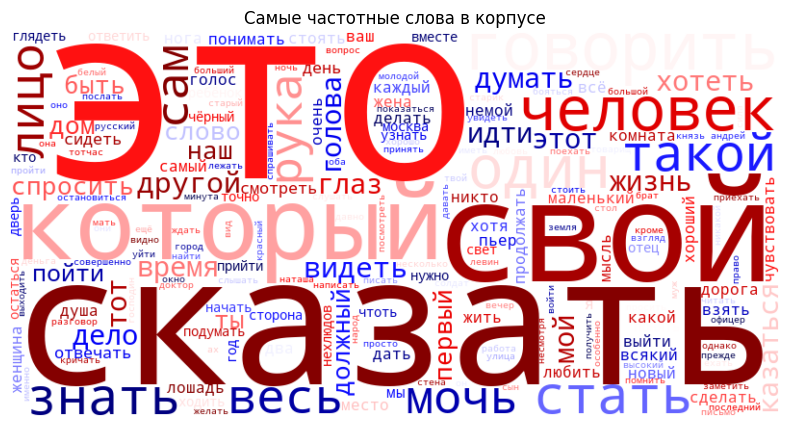

In [392]:
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='seismic').generate(" ".join(words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Самые частотные слова в корпусе")
plt.show()

In [396]:
word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=200,
    window=5,
    min_count=5,
    sg=0,
    alpha=0.025,
    min_alpha = 0.0001,
    epochs=7
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [412]:
# Делаем проверку: ищем похожие слова для...
similar_to_man = word2vec_model.wv.most_similar("мужчина", topn=5) if "мужчина" in word2vec_model.wv else None
similar_to_man

[('женщина', 0.8412417769432068),
 ('пожилой', 0.7458553314208984),
 ('девушка', 0.7332394123077393),
 ('красивый', 0.7075158357620239),
 ('когдато', 0.69598388671875)]

In [404]:
# Делаем проверку: ищем похожие слова для...
similar_to_woman = word2vec_model.wv.most_similar("женщина", topn=5) if "женщина" in word2vec_model.wv else None
similar_to_woman

[('девушка', 0.8883413076400757),
 ('мужчина', 0.8412418365478516),
 ('мальчик', 0.6869853734970093),
 ('человек', 0.6770806908607483),
 ('девочка', 0.6710284352302551)]

In [399]:
# Делаем проверку: ищем похожие слова для...
similar_to_sky = word2vec_model.wv.most_similar("небо", topn=5) if "небо" in word2vec_model.wv else None
similar_to_sky

[('солнце', 0.9125845432281494),
 ('звезда', 0.8896028399467468),
 ('луч', 0.8626554012298584),
 ('туман', 0.8618329763412476),
 ('облако', 0.8493646383285522)]

In [410]:
# Делаем проверку: ищем похожие слова для...
similar_to_horse = word2vec_model.wv.most_similar("конь", topn=5) if "конь" in word2vec_model.wv else None
similar_to_horse

[('козак', 0.8127308487892151),
 ('лошадь', 0.7934442758560181),
 ('воз', 0.7898175716400146),
 ('волк', 0.7832340598106384),
 ('сено', 0.7796661853790283)]

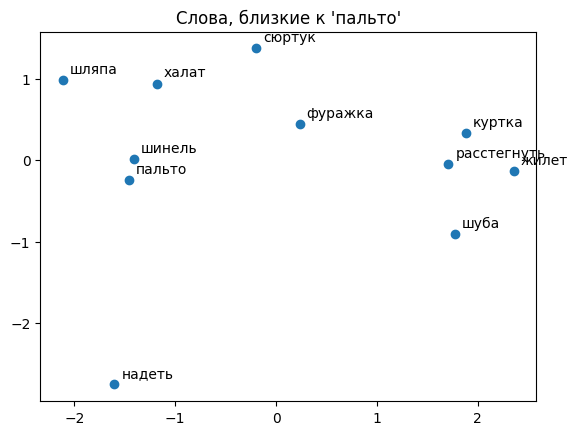

In [435]:
# Берем случайное (или не случайное) слово из словаря
# random_word = random.choice(word2vec_model.wv.index_to_key)
random_word = "пальто"

# Берем 20 близких слов
similar_words = word2vec_model.wv.most_similar(random_word, topn=10)

# Собираем список слов
words = [random_word] + [w for w, _ in similar_words]

# 3. Получаем их векторы
vectors = np.array([word2vec_model.wv[w] for w in words])

# Снижаем размерность до 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Рисуем
plt.figure()
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words):
    x, y = coords[i]
    plt.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(f"Слова, близкие к '{random_word}'")
plt.show()